# Cricket Dataset Insights

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries are loaded successfuly")

Libraries are loaded successfuly


### To commemorate the ongoing ICC Cricket World Cup we will exploring a Cricket Dataset and see how we can gain interesting insights using the Data Science Skills we have!

### Use of For loops to traverse the DATASET is not allowed!

**Question: ** Read the dataset `cricket_data.csv` and store it in a variable `cricketData`

In [ ]:
# reading dataset from drive
#import os
#print(os.path.exists(path))

from google.colab import drive
drive.mount('/content/drive',force_remount = True)
path = "/content/drive/MyDrive/ColabNotebooks/DA2/Part01/cricket_data.csv"
cricketData = pd.read_csv(path)


print(cricketData.head())

Mounted at /content/drive
        id   season        city        date        team1       team2  \
0  1389389  2023/24      Indore  2023/09/24        India   Australia   
1  1336129     2023  Nottingham  2023/09/23      England     Ireland   
2  1395701     2023       Dhaka  2023/09/23  New Zealand  Bangladesh   
3  1389388  2023/24  Chandigarh  2023/09/22    Australia       India   
4  1395700     2023       Dhaka  2023/09/21  New Zealand  Bangladesh   

    tosswinner tossdecision  result  dlapplied       winner winbyruns  \
0    Australia        field     D/L          1        India   99 runs   
1      Ireland        field  normal          0      England   48 runs   
2  New Zealand          bat  normal          0  New Zealand   86 runs   
3        India        field  normal          0        India    0 runs   
4   Bangladesh        field  normal          0          NaN    0 runs   

  winbywickets         playerofmatch  \
0    0 wickets         Ahmad SS Iyer   
1    0 wickets        

**Question ** We all know that Null values are a huge problem. Therefore, we shall begin our data cleaning process by removing all the rows that contain Null values. First store the number of null values in a variable called `numOfNullVals` and then remove them from `cricketData`.

In [ ]:

numOfNullVals = cricketData.isnull().sum()   # storing number of null values in a variable

"""
print(cricketData.info())
print(cricketData.shape)
"""
numOfNullVals = cricketData.isnull().any(axis=1).sum()
print("Number of Null Values \n ",numOfNullVals)

if numOfNullVals > 0:
    cricketData = cricketData.dropna()


Number of Null Values 
  673


**Question: ** You may have observed the game ids are now just a mix since we have dropped the null valued rows. Write a code snippet that will reset the index and start it from 1 onwards till the length of the dataframe. Rename the new index "Match ID".

In [ ]:
# reset index and start from 1 onward till the length of dataframe

cricketData['id'] = np.arange(1, len(cricketData) + 1)
cricketData.set_index('id', inplace = True)
cricketData.index.name = 'Match ID'

print(cricketData.head().sort_values(by = 'Match ID'))


           season        city        date        team1       team2  \
Match ID                                                             
1         2023/24      Indore  2023/09/24        India   Australia   
2            2023  Nottingham  2023/09/23      England     Ireland   
3            2023       Dhaka  2023/09/23  New Zealand  Bangladesh   
4         2023/24  Chandigarh  2023/09/22    Australia       India   
5            2023       Dhaka  2023/09/21  New Zealand  Bangladesh   

           tosswinner tossdecision  result  dlapplied       winner winbyruns  \
Match ID                                                                       
1           Australia        field     D/L          1        India   99 runs   
2             Ireland        field  normal          0      England   48 runs   
3         New Zealand          bat  normal          0  New Zealand   86 runs   
4               India        field  normal          0        India    0 runs   
5          Bangladesh        

**Question: ** Another important part of EDA is to make data usable. For example, the `season` column contains strings of the form '2023' or '2023/24', etc.; these as integers would open them up for further analysis. Therefore, change the values in this column to integers (all seasons of the form 2023/24 should be considered as 2024 and so on).

In [ ]:
# getting unique values of season and removing / and converting to int. keeping value after / and save with century

# using lambda function
cricketData['season'] = cricketData['season'].apply(lambda x: int(str(x).split('/')[-1]) + 2000 if '/' in x else int(x))

print(cricketData['season'])

Match ID
1       2024
2       2023
3       2023
4       2024
5       2023
        ... 
2375    2003
2376    2003
2377    2003
2378    2003
2379    2003
Name: season, Length: 2379, dtype: int64


**Question: ** Now we shall rename our columns so they make sense; all of them should be renamed to camel-case format. (e.g, tossdecision -> TossDecision)

In [ ]:
# removing _ and making eachword of columns headings camel case

cricketData.columns = cricketData.columns.str.capitalize()

# writing function to capitalize each word
def capitalize_each_word(string_name):
  words = ['toss','winner','decision','applied','by','runs','win','wickets','player','of','match',]
  for x in words:

      string_name = string_name.replace(x,x.capitalize())
  return string_name

# applying function to all columns
cricketData.columns = [capitalize_each_word(col) for col in cricketData.columns]

print(cricketData.columns)


Index(['Season', 'City', 'Date', 'Team1', 'Team2', 'TossWinner',
       'TossDecision', 'Result', 'DlApplied', 'Winner', 'WinByRuns',
       'WinByWickets', 'PlayerOfMatch', 'Venue', 'Umpire1', 'Umpire2',
       'Umpire3'],
      dtype='object')


**Question: ** Finally, have a look at the 'PlayerOfMatch' column and see if you spot a problem. If so, fix it.

In [ ]:
# truncate a specific string 'Ahmad' from  PlayerOfMatch column values
cricketData['PlayerOfMatch'] = (cricketData['PlayerOfMatch'].astype(str).str.removeprefix('Ahmad').str.lstrip())

print(cricketData['PlayerOfMatch'])

Match ID
1              SS Iyer
2             WG Jacks
3             IS Sodhi
4       Mohammed Shami
5                  nan
             ...      
2375     ST Jayasuriya
2376            Z Khan
2377          AR Adams
2378         DR Tuffey
2379          V Sehwag
Name: PlayerOfMatch, Length: 2379, dtype: object


## Moving on to Visualisation

### Another important part of EDA is to be able to visualize the Data and get a deeper understanding of the relationships within the Data.

**Question: ** First we will find out the number of wins for each team. Start by creating a dictionary called `TeamWins` where the key will be the team name and the value will be the corresponding number of wins that team has. Then plot this to be able to visualize, you must justify whichever plot type you choose. (For this question, leave out any team that has no wins)

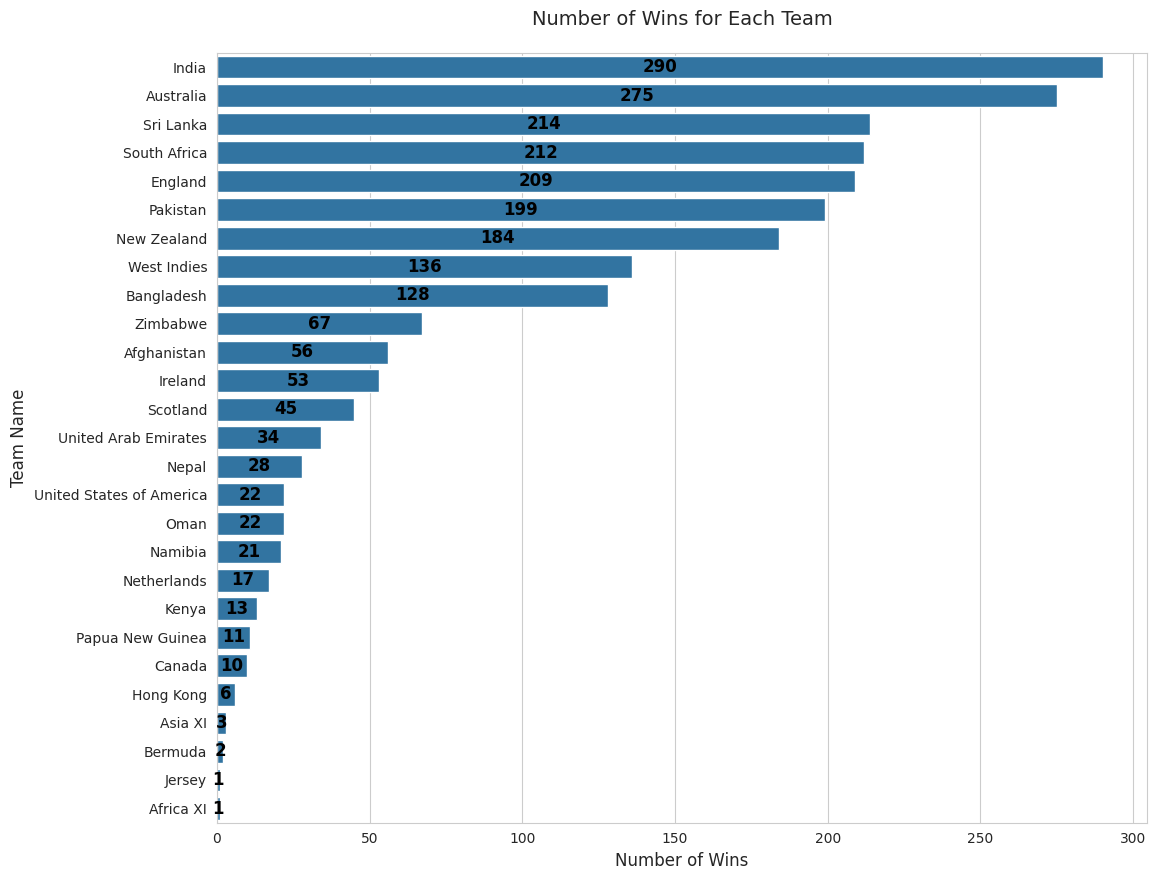

In [ ]:
# creating dictionary Teamwins with key team name and value be corresponding wins. Leaving teams with 0 wins
TeamWins = (cricketData['Winner'].value_counts().to_dict()) if cricketData['Winner'].value_counts().sum() > 0 else {}
#print(TeamWins)

df_TeamWins = pd.DataFrame(list(TeamWins.items()), columns = ['Winner', 'TeamWins'])      # converting dictionary to dataframe for plotting

# Setting style for visual display
sns.set_style('whitegrid')
plt.figure(figsize=(12, 10))

ax = sns.barplot(x= 'TeamWins', y= 'Winner', data = df_TeamWins)

# add counts on bars
for i, (Winner, TeamWins) in enumerate(zip(df_TeamWins['Winner'],df_TeamWins['TeamWins'])):
  ax.text(TeamWins /2, i, str(TeamWins), ha='center', va='center', fontsize = 12, fontweight = 'bold', color = 'black')


plt.xlabel('Number of Wins',fontsize=12)
plt.ylabel('Team Name',fontsize=12)
plt.title('Number of Wins for Each Team',fontsize=14, pad= 20)

plt.show()


We used bar chart here for visualization because bar charst are:
1. Simple to understand
2. Easy to compare different catagories at a glance by looking t lengths of bars
3. These are versatile and show trend over time.
4. Wide accesseibilty
5. Versatility
6. Summarize large data
7. Easy customization
so on

**Question: ** Next let's move on to investigate the relationship between winning the toss and winning the match, just like before create a dictionary that has the team name as key, and the probability of winning the match given the team have won the toss as value (make sure to sort it in alphabetic order of team name). Then plot your results; justify the choice of plot. (For this question, you must decide whether all teams should be included or not)

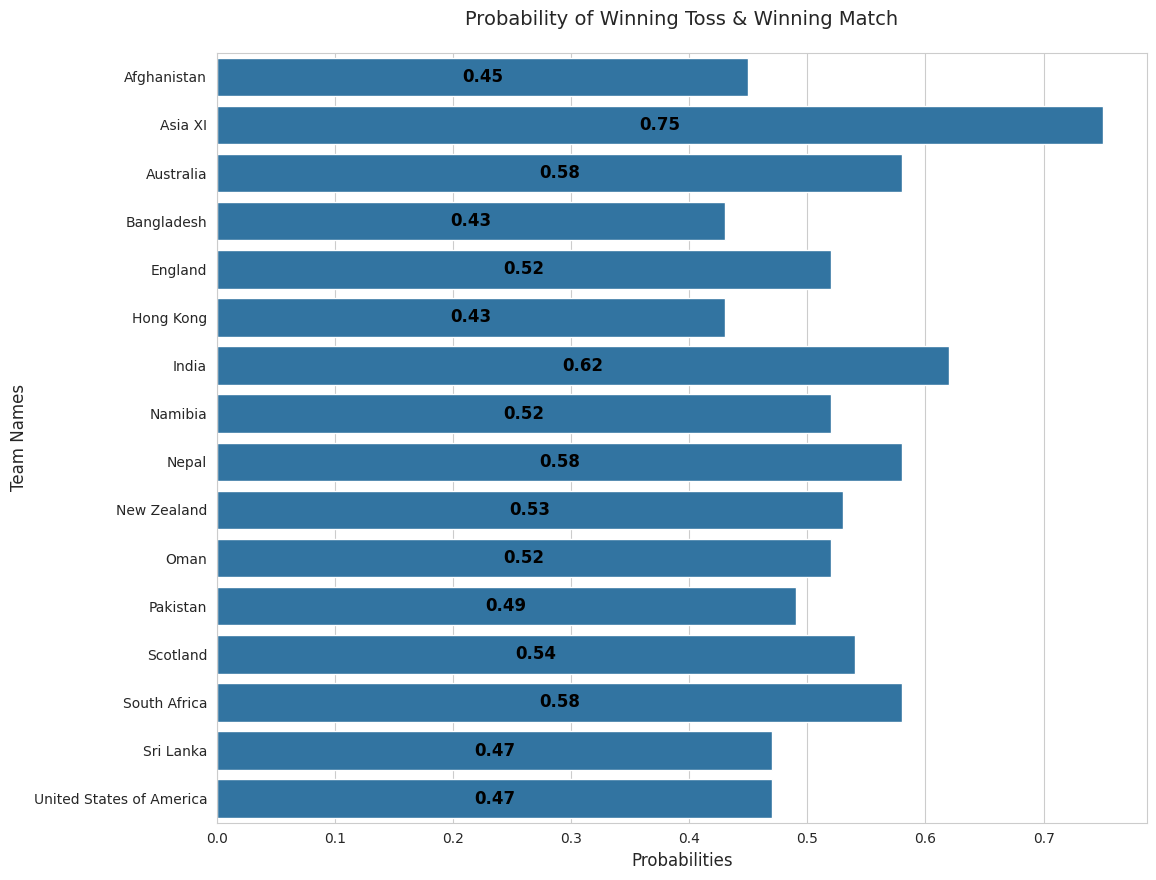

In [ ]:

toss_wins = cricketData['TossWinner'].value_counts()      # how many times each team won the toss

match_toss_wins = cricketData[cricketData['TossWinner'] == cricketData['Winner']]['TossWinner'].value_counts()    # teams who won both toss and match

Probabilities = ((match_toss_wins / toss_wins).sort_index().round(2)).to_dict()     # get prbabilities in 2 decimal places, store in dictionary and sort alphabeticaly

# converting dictionary into dataframe for plotting
df_Probabilities = pd.DataFrame(list(Probabilities.items()), columns = ['Team', 'Probability'])

df_Probabilities = df_Probabilities[df_Probabilities['Probability'] >  0.40]    # including teams with probability greater than 0.40 only
#print(df_Probabilities['Probability'])

# Styling for visualization
sns.set_style('whitegrid')
plt.figure(figsize=(12, 10))

ax = sns.barplot(x= 'Probability' , y= 'Team', data = df_Probabilities)

# add counts on bars

for i, (Team, Probability) in enumerate(zip(df_Probabilities['Team'],df_Probabilities['Probability'])):
  ax.text(Probability /2, i, str(Probability), ha='center', va='center', fontsize = 12, fontweight = 'bold', color = 'black')


plt.xlabel('Probabilities',fontsize=12)
plt.ylabel('Team Names',fontsize=12)
plt.title('Probability of Winning Toss & Winning Match',fontsize=14, pad = 20)

plt.show()

#print(df_Probabilities['Probability'])
#print(Probabilities)

We used bar chart here for visualization because bar charst are:
1. Simple to understand
2. Easy to compare different catagories at a glance by looking at lengths of bars
3. These are versatile and show trend over time.
4. Wide accesseibilty
5. Versatility
6. Summarize large data
7. Easy customization
so on

**Question: ** After doing a visual analysis, what team looks like it is the best team out of all? Save it's name in a variable called `BestTeam`. Is this a valid conclusion? Why or why not?


In [ ]:
# choosing best team from visual graph
BestTeamRecod = df_Probabilities.loc[df_Probabilities['Probability'].idxmax()]
BestTeam = BestTeamRecod['Team']
print("Best Team is : ",BestTeam)

Best Team is :  Asia XI


  

*   ***Asia XI***  is best team according to our given scenerio.

*   This seems not valid conclusion


*   Many factors depend upon choosing the best team.
    1. Considering only on toss winning connected to match winning is not best approach  specially in cricket.
    2. Pitch, weather, timing of match and home ground also plays role in winning the match
    3. Team selection for specific season is also important factor
    4. Fcators in choosing best team can include over all team fitness, consistent performance throughout the seasons, best game plan, positive team cultutre, strong leadership and winning mindset

    






**Question: ** Let's modify our approach slightly and see if we can see who the actual top teams are. We will only look at teams with more than 100 wins. Start by creating a list of team names called `topTeamList` that have wins > 100, then use that to create a dataframe called `topTeamsMatches`, in which you will have matches for ONLY the top teams (the matches they have played).

In [ ]:

TeamWins = cricketData['Winner'].value_counts()     # Count of team wins
topTeamList = TeamWins[TeamWins > 100].index.tolist()    #list of teams with more than 100 wins

topTeamsMatches = cricketData[cricketData['Team1'].isin(topTeamList) | cricketData['Team2'].isin(topTeamList)].copy()
print("Top Teams Matches are: \n" )
print(topTeamsMatches)


Top Teams Matches are: 

          Season          City        Date        Team1        Team2  \
Match ID                                                               
1           2024        Indore  2023/09/24        India    Australia   
2           2023    Nottingham  2023/09/23      England      Ireland   
3           2023         Dhaka  2023/09/23  New Zealand   Bangladesh   
4           2024    Chandigarh  2023/09/22    Australia        India   
5           2023         Dhaka  2023/09/21  New Zealand   Bangladesh   
...          ...           ...         ...          ...          ...   
2375        2003        Sydney  2003/01/09    Sri Lanka    Australia   
2376        2003    Wellington  2003/01/08  New Zealand        India   
2377        2003    Queenstown  2003/01/04        India  New Zealand   
2378        2003  Christchurch  2003/01/01        India  New Zealand   
2379        2003        Napier  2002/12/29  New Zealand        India   

           TossWinner TossDecision  Re

**Question: ** Now that we have the 'Good' teams, let us see which ones are statistically better that others. Find the win rate of each good team, store it in a dictionary like you have been doing before. Name it `topTeamsWinRate`. Plot this information and now comment on who might be the top team (store the name in `actualBestTeam`) and whether this is a better comparison than what we did before.

Actual Best Teams is:  Australia


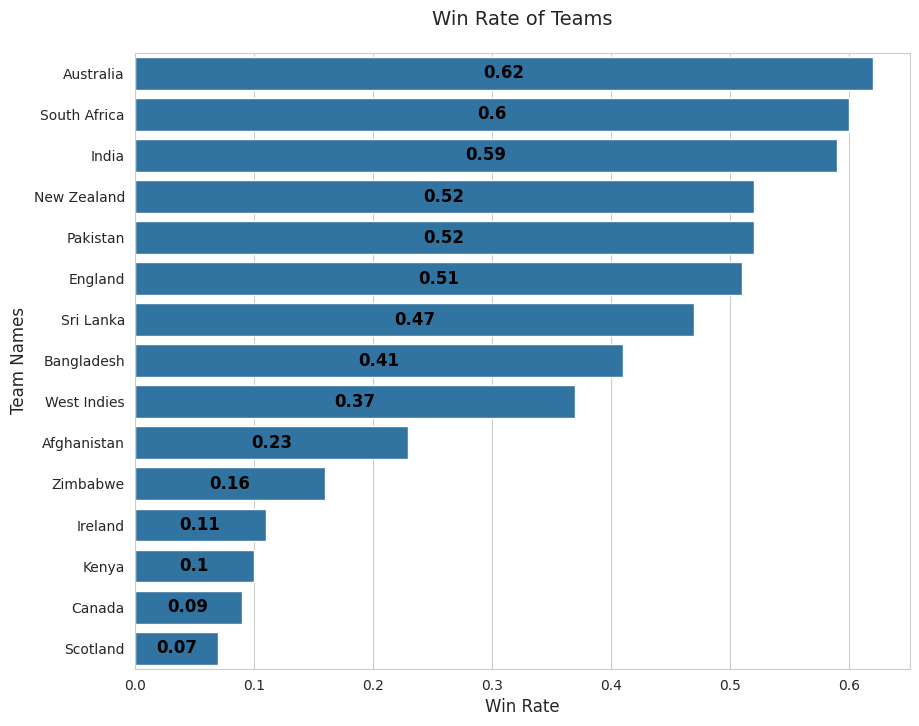

In [ ]:

topTeamsMatchesCount = topTeamsMatches['Team1'].value_counts() + topTeamsMatches['Team2'].value_counts()    #top teams total matches
topTeamsWinMatches = topTeamsMatches['Winner'].value_counts()         #top teams winning matches

topTeamsWinRate = ((topTeamsWinMatches / topTeamsMatchesCount).round(2)).to_dict()        #win rate of top teams

df_winrate = (pd.DataFrame(list(topTeamsWinRate.items()), columns=['Team', 'WinRate']).sort_values('WinRate', ascending=False))   #converting to data frame
df_winrate = df_winrate.dropna(subset=['WinRate'])      # for plotting chart, excluding teams with no win rate
actualBestTeam = df_winrate.loc[df_winrate['WinRate'].idxmax(), 'Team']       # actual best team

print("Actual Best Teams is: ",actualBestTeam)
#print(actualBestTeam)

sns.set_style('whitegrid')
plt.figure(figsize=(10, 8))

ax = sns.barplot(x= 'WinRate' , y= 'Team', data = df_winrate)

# add counts on bars

for i, (Team, WinRate) in enumerate(zip(df_winrate['Team'],df_winrate['WinRate'])):
  ax.text(WinRate /2, i, str(WinRate), ha='center', va='center', fontsize = 12, fontweight = 'bold', color = 'black')


plt.xlabel('Win Rate',fontsize=12)
plt.ylabel('Team Names',fontsize=12)
plt.title('Win Rate of Teams',fontsize=14, pad = 20)

plt.show()


This is **fair and strong statistical comparison** as we filtered teams that are already good so all are in similar strength category. Since weak teams are removed bias is reduced.
In other question a team might have won toss 2 times so 2/2 makes 100% win. But small number of toss wins can distort the probability. To remove this bias we filtered teams with small number of toss wins. so teams are almost at same level of performance now.




We used bar chart here for visualization because bar charst are:
1. Simple to understand
2. Easy to compare different catagories at a glance by looking t lengths of bars
3. These are versatile and show trend over time.
4. Wide accesseibilty
5. Versatility
6. Summarize large data
7. Easy customization
so on

### Warning: Use for topTeamsMatches ends here

## Pakistan vs India

**Question: ** Now lets see which team is superior. Start by creating two dictionaries that contain the number of wins for Pakistan and India per season in variables called `PakWins` and `IndWins` respectively (they might not have the same length)
Then Create 4 Variables called `MeanPak`, `StdPak`, `MeanInd`, and `StdInd`. Which will contain the Means and Standard Deviations of the number of wins over the course of all seasons.

In [ ]:
# creating dictionary that contains number of wins for pakistan per season

PakWins = cricketData[cricketData['Winner'] == 'Pakistan']['Season'].value_counts().sort_index().to_dict()
IndWins = cricketData[cricketData['Winner'] == 'India']['Season'].value_counts().sort_index().to_dict()

#converting to list
PakWinsList = list(PakWins.values())
IndWinsList = list(IndWins.values())
#print(PakWinsList)

# converting to 2 decimal places
MeanPak = np.mean(list(PakWins.values())).round(2)
StdPak = np.std(list(PakWins.values())).round(2)
print("Pakistan Wins Stats:" )
print("Mean: ",MeanPak)
print("SDtd: ",StdPak)
print("\n")
MeanInd = np.mean(list(IndWins.values())).round(2)
StdInd = np.std(list(IndWins.values())).round(2)
print("India Wins Stats:" )
print("Mean: ",MeanInd)
print("SDtd: ",StdInd)



Pakistan Wins Stats:
Mean:  9.48
SDtd:  3.94


India Wins Stats:
Mean:  13.18
SDtd:  5.43


**Question: ** Convert the columns `WinByRuns` and `WinByWickets` to int and remove the string aspects from them.

In [ ]:
# convert columns to int and remove string aspects from them
cricketData['WinByRuns'] = cricketData['WinByRuns'].astype(str).str.extract(r'(\d+)')[0].astype(int)
print("Wins by Runs: \n")
print(cricketData['WinByRuns'])

cricketData['WinByWickets'] = cricketData['WinByWickets'].astype(str).str.extract(r'(\d+)')[0].astype(int)
print("\n")
print("Wins by Wickets: \n")
print(cricketData['WinByWickets'])


Wins by Runs: 

Match ID
1       99
2       48
3       86
4        0
5        0
        ..
2375    79
2376     0
2377     0
2378     0
2379    35
Name: WinByRuns, Length: 2379, dtype: int64


Wins by Wickets: 

Match ID
1       0
2       0
3       0
4       5
5       0
       ..
2375    0
2376    2
2377    7
2378    5
2379    0
Name: WinByWickets, Length: 2379, dtype: int64


**Question: ** Now that we have integers to work with, we can do some plotting. Like always, first make dictionary that contains the team name as key and the average number of runs a team wins by, given that they have won the match as value. Plot a barplot of the average number of runs a team wins by, given that they have won the match.

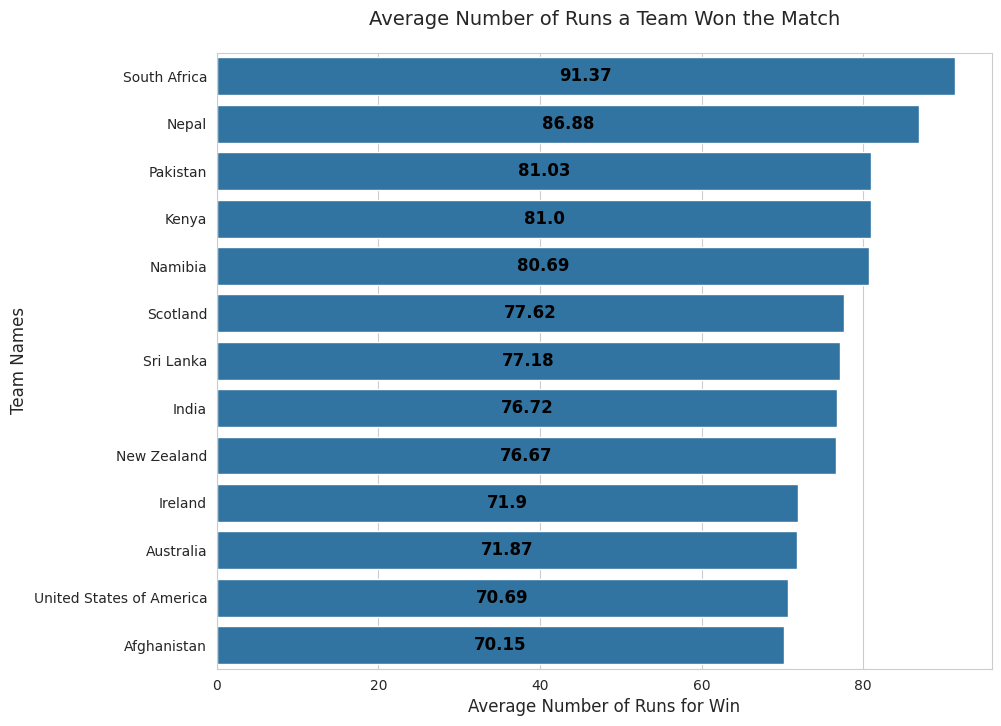

In [ ]:

matches_won_by_run = cricketData[cricketData['WinByRuns'] > 0]     # select matches won by run only

AvgWinRuns = matches_won_by_run.groupby('Winner')['WinByRuns'].mean().sort_values(ascending = False).to_dict()

# creating dictionary of averahe runs per team
for key, value in AvgWinRuns.items():
  AvgWinRuns[key] = round(value,2)

# convert dictionary to dataframe
df_AvgRuns = pd.DataFrame(list(AvgWinRuns.items()), columns = ['TeamName', 'AvgWinByRuns']).sort_values('AvgWinByRuns', ascending = False)

df_AvgRuns = df_AvgRuns[df_AvgRuns['AvgWinByRuns'] > 70]       # choosingg records greater than 70 average
#print(df_AvgRuns)

sns.set_style('whitegrid')
plt.figure(figsize=(10, 8))

ax = sns.barplot(x= 'AvgWinByRuns' , y= 'TeamName', data = df_AvgRuns)

# add counts on bars
for i, (TeamName, AvgWinByRuns) in enumerate(zip(df_AvgRuns['TeamName'],df_AvgRuns['AvgWinByRuns'])):
  ax.text(AvgWinByRuns /2, i, str(AvgWinByRuns), ha='center', va='center', fontsize = 12, fontweight = 'bold', color = 'black')


plt.xlabel('Average Number of Runs for Win',fontsize=12)
plt.ylabel('Team Names',fontsize=12)
plt.title('Average Number of Runs a Team Won the Match',fontsize=14, pad = 20)

plt.show()


**Question: ** We want to see who has been the most impactful player for Pakistan over the years. First find the list of players who have been awarded the man of the match and the amount of times they have been awareded. Store this in a dictionary called `PakManOfMatchCount`.

Keep in mind how usually the winning team is awarded the man of the match.

Also comment on whether simply checking which player has won the most man of the match awards is a good insight into who has been the best player of Pakistan? Make sure you are able to justify whatever claim you make.

In [ ]:

pakWins = cricketData[(cricketData['Winner'] == 'Pakistan')]          # count man of the match for pakistan
PakManOfMatchCount = pakWins['PlayerOfMatch'].value_counts().to_dict()
print("\n")
print("Pakistan Man of Match Count: ", PakManOfMatchCount)



Pakistan Man of Match Count:  {'Shahid Afridi': 19, 'Mohammad Hafeez': 18, 'Babar Azam': 13, 'Shoaib Malik': 12, 'Younis Khan': 10, 'Abdul Razzaq': 9, 'Umar Akmal': 7, 'Misbah-ul-Haq': 6, 'Ahmed Shehzad': 6, 'Fakhar Zaman': 6, 'Mohammad Yousuf': 6, 'Sarfraz Ahmed': 5, 'Salman Butt': 5, 'Kamran Akmal': 4, 'Usman Shinwari': 4, 'Yasir Hameed': 4, 'Nasir Jamshed': 3, 'Naved-ul-Hasan': 3, 'Umar Gul': 3, 'Sohail Tanvir': 3, 'Shadab Khan': 3, 'Imam-ul-Haq': 3, 'Shaheen Shah Afridi': 2, 'Haris Sohail': 2, 'Hasan Ali': 2, 'Naseem Shah': 2, 'Mohammad Nawaz (3)': 2, 'Haris Rauf': 2, 'Aizaz Cheema': 2, 'Inzamam-ul-Haq': 2, 'Mohammad Sami': 2, 'Sohaib Maqsood': 1, 'nan': 1, 'Wahab Riaz': 1, 'Azhar Ali': 1, 'Yasir Shah': 1, 'Khushdil Shah': 1, 'Iftikhar Ahmed': 1, 'BRM Taylor': 1, 'Mohammad Rizwan': 1, 'Abid Ali': 1, 'Bilal Asif': 1, 'Imad Wasim': 1, 'Faheem Ashraf': 1, 'MS Dhoni': 1, 'Nasir Hossain': 1, 'MN Samuels': 1, 'Mohammad Irfan': 1, 'Anwar Ali': 1, 'Abdur Rauf': 1, 'Mohammad Asif': 1, 'CH

I assumed here that 'Man of the Match' award goes to winning team. So filtering matches where pakistan was winner would solve the problem of Pakistani man of the match list.


Claiming "**Best Player**" only on basis of "**Man of the Match**" can not be the only criteria although its high performance award.


**Factors defining the "Best Player"**
Some of factors in defining the best player could be:

1. His overall statistics throughout the career should be considered
2. Ability to perform for a sustained period
3. His impact and dominance over the peers. Does he consistently creatres the impact and lead the team to win.
4. Number of titles and championships won, broader impact on sport and influence on fans, also considered important



**Question: ** For all seasons, find the player that has been the most frequent Man of the match for Pakistan. There might be people with the same number of wins, in that case give sequential preference. Store in a dictionary, where key is season and value is the name of the player.

In [ ]:
# pakistani man of the match for each season. give sequential preference and store in dictionary
pak_wins = cricketData[cricketData['Winner'] == 'Pakistan'].copy()


season_player_counts = pak_wins.groupby(['Season', 'PlayerOfMatch']).size().reset_index(name='count')

season_player_counts = season_player_counts.sort_values(by=['Season', 'count'], ascending=[True, False])      #sort values

top_player_per_season = season_player_counts.drop_duplicates(subset='Season', keep='first')       # picking top row per season

PakManOfMatchSeason = dict(zip(top_player_per_season['Season'],top_player_per_season['PlayerOfMatch']))       # build dictionary PakManOfMatchSeason

print("Pakistani Team's Man of the Match in each Season: \n")
# print dictionary
for season, player in PakManOfMatchSeason.items():
  print(f"{season}: {player}")



Pakistani Team's Man of the Match in each Season: 

2003: Mohammad Hafeez
2004: Mohammad Sami
2005: Abdul Razzaq
2006: Younis Khan
2007: Naved-ul-Hasan
2008: Younis Khan
2009: CH Gayle
2010: Shahid Afridi
2011: Mohammad Hafeez
2012: Shahid Afridi
2013: Misbah-ul-Haq
2014: Mohammad Hafeez
2015: Ahmed Shehzad
2016: Bilal Asif
2017: Babar Azam
2018: Babar Azam
2019: Mohammad Hafeez
2020: Abid Ali
2021: Babar Azam
2022: Babar Azam
2023: Babar Azam


**Question: ** Lets now analyze more recent performance of the teams. For the last 3 seasons, plot the distribution of `WinByRuns` for the top 10 teams with most wins. For each time, overlay the distribution of each season on the same plot. Comment on what you observe.

[2024, 2023, 2022]


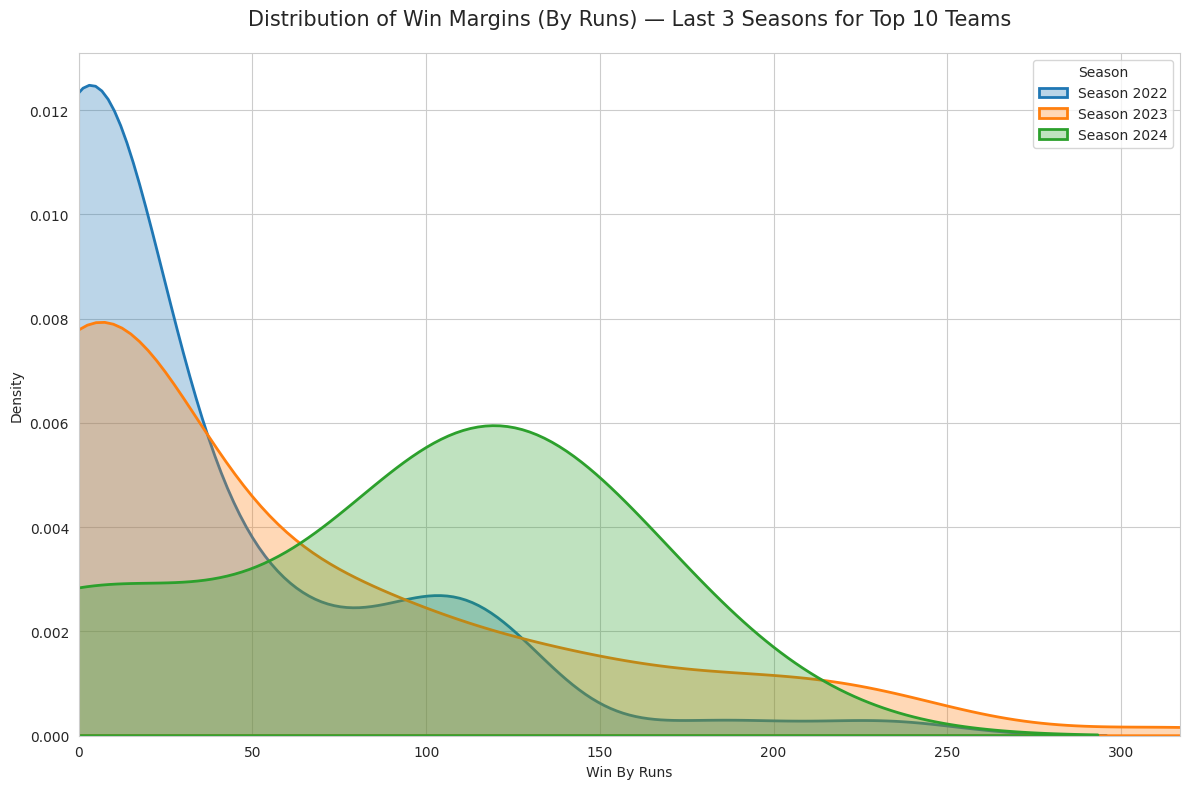

In [ ]:

top_10_teams = cricketData.groupby('Winner')['WinByRuns'].sum().nlargest(10).index.tolist()     # top 10 teams in WinByRuns with most wins

top_10_matches = cricketData[cricketData['Winner'].isin(top_10_teams)]        # matches won by these top 10 teams

last_3_seasons = sorted(top_10_matches['Season'].unique())[-3:][::-1]
last_3_seasons = list(map(int, last_3_seasons))
print(last_3_seasons)

recent_data = top_10_matches[top_10_matches['Season'].isin(last_3_seasons)]       # filtering last 3 seasons for top 10 teams
#print(recent_data)

# Style setting for visualization
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

for season in sorted(recent_data['Season'].unique()):
    sns.kdeplot(
        data=recent_data[recent_data['Season'] == season],
        x='WinByRuns',
        fill=True,
        alpha=0.3,
        linewidth=2,
        label=f"Season {season}"
    )

plt.title("Distribution of Win Margins (By Runs) — Last 3 Seasons for Top 10 Teams", fontsize=15, pad=20)
plt.xlabel("Win By Runs")
plt.ylabel("Density")
plt.legend(title="Season", fontsize=10)
plt.xlim(0, recent_data['WinByRuns'].max())
plt.tight_layout()
plt.show()


***Observations From Kernal Density Estimate (KDE) Plot:***

. Each curve in KDE represents distributions of win margins (by runs) for particular season.
. We are considering latest three seasons for our visualization, i.e; 2022, 2023 and 2014
. Considering win margins for top 10 teams
. X-axis shows the "win By Runs" i.e; number of runs a team won by.
. Y-axis shows probability. i.e; how frequently certain win margins occur
. Each colored curve shows a specific season. The shape, height and position of each curve gives details about competitiveness from one season to another

***Seasons Analysis through curves shape, height & position:***

***Season 2022*** is represented by blue curve. Its right skewed curve which means more data is concentrated on left side. There were many small-margins wins with few large blowouts. This means these were close matches. Matches were more tighter and cpmpetitive. It has taller/ narrow peak which means teams often won by similar margins.

***Season 2023***  is represented by orange curve. ITs a wider curve which shows more variations in how big wins were. This curve is wider and flatter which shows great variations. some wins were tight and others were massive. It shows unpredictibility as well. Some teams crushed opponents and and others barely won game.

***Season 2024*** This season is represented by green curve. This curve is left skewed which means more data is concentrated on right side. Since curve is more right shifted it means recent matches were won by large margins showing the dominent victories of the top teams


**Question: ** Similarly, for all seasons, find the team that Pakistan has defeated the most frequently. Store your results in a dictionary called `mostDefeatedTeam`, where key is the season and the team name is value.

In [ ]:

pak_wins = cricketData[cricketData['Winner'] == 'Pakistan'].copy()    # filtering matches won by Pakistan

pak_wins['defeated'] = pak_wins.apply(
    lambda x: x['Team2'] if x['Team1'] == 'Pakistan' else x['Team1'],
    axis=1
)             # teams defeated by pakistan

#seasons defeat
season_defeats = (
    pak_wins.groupby(['Season', 'defeated'])
            .size()
            .reset_index(name='count')
)

season_defeats = season_defeats.sort_values(['Season', 'count'], ascending=[True, False])     # sorting values

top_defeated = season_defeats.drop_duplicates(subset='Season', keep='first')          #dropping duplicates

mostDefeatedTeam = dict(zip(top_defeated['Season'], top_defeated['defeated']))        # build dictionary
print("Most Defeated Team by Pakistan in each Season: \n")
for season in sorted(mostDefeatedTeam):
    print(f"{season}: {mostDefeatedTeam[season]}")


Most Defeated Team by Pakistan in each Season 

2003: Bangladesh
2004: India
2005: West Indies
2006: England
2007: West Indies
2008: Bangladesh
2009: Sri Lanka
2010: England
2011: West Indies
2012: Sri Lanka
2013: West Indies
2014: Sri Lanka
2015: Sri Lanka
2016: England
2017: West Indies
2018: Sri Lanka
2019: South Africa
2020: Sri Lanka
2021: South Africa
2022: Netherlands
2023: New Zealand


**Question: ** What further insightful analysis or questions do you think could be useful in extracting some valuable information from the dataset?

**Further Insightful Analysis Suggestions**

Further insightful analysis can be done to extract valuable information. Some examples could be:

1. Venue based performance(may be if we get pitch condition or general trend of winning   at specific venue)
2. Impact of city/venue vs toss decisions or
   venue vs win by runs or win by wickets
3. Home vs away performance   
4. Umpires influence on runs/ wickets
5. Win trends by season
6. which team prefers bowling or batting first
7. Teams winning trends. (with big margins or smaller)
8. Which team got most 'Man of the Match' awrds in specific season
9. Which player got 'Man of the Match' title more often in specific season
10. Team that defeated Pakistn mostly in specific season
11. Win by highest run margins (best for batting). (check venue/season/team)
12. venue/season/team Better for bowling (win by wickets)
so on

...

# The End!